# First Step: Explorarity Data Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Reading data

In [6]:
raw_data_path = "/Users/omerburaksal/Desktop/projects/data_science/product_level_mobile/data/raw/mobile_app_usage_screen_time.csv"

In [8]:
raw_data_df = pd.read_csv(raw_data_path)

In [9]:
raw_data_df.head()

,record_id,year,month,quarter,day_of_week,country,age_group,gender,device_brand,operating_system,...,app_rating_given,review_submitted,primary_usage_time,dark_mode_preference,location_permission,sleep_disruption_from_phone,screen_time_concern,mental_health_impact,digital_wellbeing_feature_used,app_deleted_and_reinstalled
0,APP0000001,2024,11,Q4,Thursday,Turkey,45-54,Male,Xiaomi,Android,...,4,No,Lunch (12-2pm),Sometimes,While Using,Moderate,Yes,Positive,Yes,Yes
1,APP0000002,2022,5,Q2,Friday,USA,25-34,Male,Huawei,Android,...,4,Yes,Evening (6-10pm),Sometimes,Never,NaN,Yes,Negative,Yes,Yes
2,APP0000003,2024,9,Q3,Sunday,USA,25-34,Male,Samsung,Android,...,4,Yes,Evening (6-10pm),Sometimes,While Using,NaN,No,Negative,No,Yes
3,APP0000004,2023,7,Q3,Tuesday,Pakistan,25-34,Male,Samsung,Android,...,4,No,Commute (9-11am),Never,Always,Moderate,Somewhat,Negative,Yes,No
4,APP0000005,2023,3,Q1,Tuesday,UAE,25-34,Male,OnePlus,Android,...,1,No,Commute (9-11am),Always,Not Applicable,Moderate,Yes,Neutral,Yes,No


In [11]:
raw_data_df.shape

(10000, 34)

In [12]:
raw_data_df.info()
raw_data_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   record_id                       10000 non-null  str    
 1   year                            10000 non-null  int64  
 2   month                           10000 non-null  int64  
 3   quarter                         10000 non-null  str    
 4   day_of_week                     10000 non-null  str    
 5   country                         10000 non-null  str    
 6   age_group                       10000 non-null  str    
 7   gender                          10000 non-null  str    
 8   device_brand                    10000 non-null  str    
 9   operating_system                10000 non-null  str    
 10  network_connection              10000 non-null  str    
 11  app_category                    10000 non-null  str    
 12  app_name                        10000 non-nu

,year,month,daily_screen_time_minutes,session_duration_minutes,sessions_per_day,app_opens_per_day,data_used_mb_per_day,battery_drain_pct_per_session,notifications_received_per_day,monthly_spend_usd,app_rating_given
count,10000.00000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2023.12990,6.553800,85.500640,35.68338,6.02530,8.023700,209.452250,18.481170,25.006400,7.840883,3.907900
std,0.77813,3.434397,70.969522,23.97657,2.43217,2.789537,306.113715,9.545508,5.056057,19.273629,1.057795
min,2022.00000,1.000000,5.700000,2.00000,1.00000,1.000000,6.100000,2.000000,9.000000,0.000000,1.000000
25%,2023.00000,4.000000,35.500000,17.50000,4.00000,6.000000,45.600000,10.200000,21.000000,0.000000,3.000000
50%,2023.00000,7.000000,63.400000,29.90000,6.00000,8.000000,96.150000,18.400000,25.000000,0.000000,4.000000
75%,2024.00000,10.000000,112.700000,48.70000,8.00000,10.000000,241.775000,26.700000,28.000000,7.450000,5.000000
max,2024.00000,12.000000,600.000000,119.90000,15.00000,21.000000,3852.100000,35.000000,49.000000,350.390000,5.000000


In [13]:
raw_data_df.isnull().sum()

record_id                            0
year                                 0
month                                0
quarter                              0
day_of_week                          0
country                              0
age_group                            0
gender                               0
device_brand                         0
operating_system                     0
network_connection                   0
app_category                         0
app_name                             0
subscription_type                    0
daily_screen_time_minutes            0
session_duration_minutes             0
sessions_per_day                     0
app_opens_per_day                    0
data_used_mb_per_day                 0
battery_drain_pct_per_session        0
notifications_received_per_day       0
notification_settings                0
in_app_purchase                      0
monthly_spend_usd                    0
app_rating_given                     0
review_submitted         

In [19]:
features = raw_data_df.columns
print(features)

Index(['record_id', 'year', 'month', 'quarter', 'day_of_week', 'country',
       'age_group', 'gender', 'device_brand', 'operating_system',
       'network_connection', 'app_category', 'app_name', 'subscription_type',
       'daily_screen_time_minutes', 'session_duration_minutes',
       'sessions_per_day', 'app_opens_per_day', 'data_used_mb_per_day',
       'battery_drain_pct_per_session', 'notifications_received_per_day',
       'notification_settings', 'in_app_purchase', 'monthly_spend_usd',
       'app_rating_given', 'review_submitted', 'primary_usage_time',
       'dark_mode_preference', 'location_permission',
       'sleep_disruption_from_phone', 'screen_time_concern',
       'mental_health_impact', 'digital_wellbeing_feature_used',
       'app_deleted_and_reinstalled'],
      dtype='str')


array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'daily_screen_time_minutes'}>],
       [<Axes: title={'center': 'session_duration_minutes'}>,
        <Axes: title={'center': 'sessions_per_day'}>,
        <Axes: title={'center': 'app_opens_per_day'}>],
       [<Axes: title={'center': 'data_used_mb_per_day'}>,
        <Axes: title={'center': 'battery_drain_pct_per_session'}>,
        <Axes: title={'center': 'notifications_received_per_day'}>],
       [<Axes: title={'center': 'monthly_spend_usd'}>,
        <Axes: title={'center': 'app_rating_given'}>, <Axes: >]],
      dtype=object)

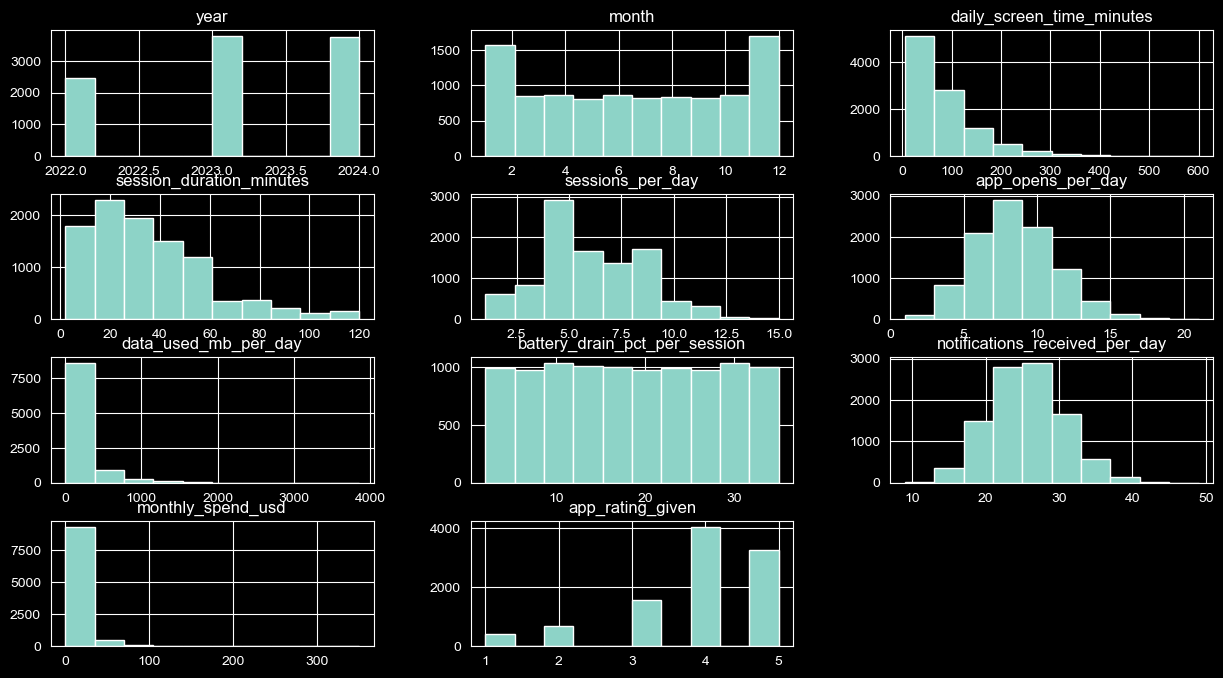

In [15]:
raw_data_df.hist(figsize=(15,8))

In [24]:
raw_data_df.nunique()

record_id                         10000
year                                  3
month                                12
quarter                               4
day_of_week                           7
country                              15
age_group                             7
gender                                3
device_brand                         10
operating_system                      2
network_connection                    5
app_category                         12
app_name                             94
subscription_type                     5
daily_screen_time_minutes          2359
session_duration_minutes           1069
sessions_per_day                     15
app_opens_per_day                    21
data_used_mb_per_day               4093
battery_drain_pct_per_session       331
notifications_received_per_day       39
notification_settings                 4
in_app_purchase                       2
monthly_spend_usd                  2142
app_rating_given                      5
